# 02 — PostgreSQL Pipeline

**Người thực hiện:** Cao Tấn Phát - Database

## 1. Mục tiêu của Notebook, vai trò của PostgreSQL trong dự án và kiến trúc pipeline

### 1.1. Mục tiêu của Notebook


Notebook này xây dựng nền tảng dữ liệu cho toàn bộ dự án bằng PostgreSQL, dựa trên năm bộ dữ liệu có cấp quan sát khác nhau: **Global, Country, State, City** và **Major City**. Các mục tiêu cụ thể gồm:

1. Import đầy đủ năm file CSV vào PostgreSQL và bảo toàn dữ liệu nguồn trong staging layer.
2. Kiểm tra row count, kiểu dữ liệu, primary key và duplicate sau import.
3. Chuẩn hóa dữ liệu thành các bảng dimension và fact có quan hệ rõ ràng.
4. Thực hiện join đúng grain, kiểm tra mất dữ liệu và ngăn row multiplication.
5. Tạo monthly analytical views, materialized views và indexes phục vụ các bước phân tích tiếp theo.
6. Hoàn thành final audit và bàn giao nguồn dữ liệu nhất quán cho Notebook 03.

### 1.2. Vai trò của PostgreSQL trong dự án

PostgreSQL không chỉ là nơi lưu trữ CSV sau import mà còn là **nền tảng quản lý và xử lý dữ liệu trung tâm** của dự án. PostgreSQL đảm nhận các vai trò sau:

- **Lưu trữ tập trung:** quản lý năm bộ dữ liệu trong cùng một database, thay vì để các notebook đọc rời rạc từ nhiều file CSV.
- **Bảo đảm tính toàn vẹn:** sử dụng data type, primary key, foreign key, UNIQUE và CHECK constraints để kiểm soát cấu trúc và quan hệ dữ liệu.
- **Tích hợp dữ liệu:** thực hiện chuẩn hóa, join và aggregation trực tiếp bằng SQL, đồng thời kiểm tra unmatched rows và row multiplication.
- **Tối ưu truy vấn:** sử dụng indexes, views và materialized views để hỗ trợ truy vấn trên dữ liệu City có hơn năm triệu dòng.
- **Bảo toàn khả năng truy vết:** cột `source_staging_id` trong các fact tables cho phép đối chiếu bản ghi phân tích với dòng staging ban đầu.
- **Tạo nguồn dữ liệu thống nhất:** Notebook 03 và các notebook sau đọc dữ liệu từ PostgreSQL thay vì quay lại CSV, giúp pipeline nhất quán và gần với quy trình triển khai thực tế.
- **Hỗ trợ tái lập và bàn giao:** database có thể được backup, restore và kiểm tra lại trên máy của các thành viên khác trong nhóm.

### 1.3. Kiến trúc pipeline

```text
5 CSV gốc
   ↓ PostgreSQL COPY
Staging layer
   ↓ chuẩn hóa khóa, địa điểm và tọa độ
Dimension + Fact layer
   ↓
Monthly analytical views
   ↓
Join validation + Aggregation + Index
   ↓
Final audit
   ↓
Monthly views bàn giao cho Notebook 03
```

Các nguyên tắc thiết kế chính:

- Staging giữ dữ liệu gần với CSV và không thực hiện data cleaning.
- Không join trực tiếp các bảng khác grain để tạo một bảng lớn gây row explosion.
- Mỗi fact giữ `source_staging_id` để duy trì data lineage.
- Monthly views là data contract chính được bàn giao cho Notebook 03.


## 2. Chuẩn bị môi trường Python, cài đặt thư viện và kết nối PostgreSQL

Mục 2 sử dụng Python để chuẩn bị môi trường và kiểm tra khả năng kết nối PostgreSQ

### 2.1. Cài đặt thư viện Python

Các thư viện được sử dụng gồm:

- `pandas`: hỗ trợ đọc kết quả truy vấn trong các notebook tiếp theo.
- `psycopg2-binary`: PostgreSQL driver dùng để kiểm tra kết nối trực tiếp.
- `SQLAlchemy`: tạo database engine chuẩn hóa cho `pd.read_sql()` và các notebook sau.

### 2.2. Kết nối Database

Trong mục này, Python được dùng để thiết lập kết nối tới PostgreSQL đang chạy cục bộ. Kết nối ban đầu sử dụng database bảo trì `postgres`, vì database phân tích `climate_db` sẽ được tạo và xác nhận ở Mục 3.

Các hằng số `DB_HOST`, `DB_PORT`, `DB_NAME`, `DB_USER` và `DB_PASSWORD` chứa thông tin kết nối trên máy đang chạy notebook. Người thực hiện cần thay đổi các giá trị này nếu cấu hình PostgreSQL cục bộ khác với ví dụ. `connection_config` được dùng cho `psycopg2`, còn `URL.create()` tạo URL kết nối cho SQLAlchemy và xử lý an toàn các ký tự đặc biệt trong mật khẩu.

Cell code tạo hai đối tượng để sử dụng trong Mục 2.3: kết nối trực tiếp `pg_connection` của `psycopg2` và `engine` của SQLAlchemy.

In [2]:
# Nhập các thư viện cần thiết để kết nối PostgreSQL bằng Python.
import pandas as pd
import psycopg2
from sqlalchemy import URL, create_engine

# Cấu hình PostgreSQL cục bộ; thay đổi nếu máy sử dụng host, port hoặc user khác.
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'postgres'  # Database bảo trì có sẵn sau khi cài PostgreSQL.
DB_USER = 'postgres'
DB_PASSWORD = '123'
connection_config = {
    'host': DB_HOST,
    'port': DB_PORT,
    'dbname': DB_NAME,
    'user': DB_USER,
    'password': DB_PASSWORD,
    'connect_timeout': 10,
}

try:
    # psycopg2 mở kết nối trực tiếp để thực thi và kiểm tra câu lệnh SQL.
    pg_connection = psycopg2.connect(**connection_config)

    # URL.create xử lý ký tự đặc biệt trong mật khẩu an toàn hơn việc ghép chuỗi.
    sqlalchemy_url = URL.create(
        drivername='postgresql+psycopg2',
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME,
    )
    engine = create_engine(sqlalchemy_url, pool_pre_ping=True)
except psycopg2.Error as error:
    raise ConnectionError(
        'Không thể kết nối PostgreSQL. Hãy kiểm tra service, host, port, user và mật khẩu.'
    ) from error

print(f'Đã mở kết nối psycopg2 tới {DB_HOST}:{DB_PORT}/{DB_NAME}.')
print('Đã khởi tạo SQLAlchemy engine để kết nối PostgreSQL.')

Đã mở kết nối psycopg2 tới localhost:5432/postgres.
Đã khởi tạo SQLAlchemy engine để kết nối PostgreSQL.


Khi cell chạy thành công, dòng output đầu tiên xác nhận `psycopg2` đã mở kết nối tới database bảo trì `postgres`. Điều đó cho thấy PostgreSQL server đang hoạt động và chấp nhận host, port, user cùng mật khẩu đã khai báo. Dòng output thứ hai chỉ xác nhận SQLAlchemy engine đã được khởi tạo; engine chưa mở kết nối thật cho đến khi truy vấn `SELECT 1` được thực hiện trong Mục 2.3.

Nếu xuất hiện `ConnectionError`, chưa nên tiếp tục pipeline. Cần kiểm tra PostgreSQL service, host, port, user và mật khẩu trong cell cấu hình.

### 2.3. Kiểm tra kết nối PostgreSQL bằng Python


Mục này kiểm tra hai cơ chế kết nối đã tạo ở Mục 2.2 bằng các truy vấn chỉ đọc. Với `psycopg2`, truy vấn trả về database hiện tại, user hiện tại và phiên bản PostgreSQL. Với SQLAlchemy, `SELECT 1` được dùng làm phép kiểm tra kết nối tối thiểu.

Kết quả được trình bày thành bảng để người chạy dễ đối chiếu. Dù truy vấn thành công hay phát sinh lỗi, kết nối và engine đều được đóng ở cuối cell để giải phóng tài nguyên.

In [3]:
# text được nhập tại đây vì chỉ Mục 2.3 cần thực thi SQL qua SQLAlchemy.
from sqlalchemy import text

try:
    # Xác minh database, user và phiên bản server bằng psycopg2.
    with pg_connection.cursor() as cursor:
        cursor.execute(
            'SELECT current_database(), current_user, version();'
        )
        current_database, current_user, server_version = cursor.fetchone()

    # Buộc SQLAlchemy engine mở kết nối thật và thực thi truy vấn tối thiểu.
    with engine.connect() as sqlalchemy_connection:
        sqlalchemy_check = sqlalchemy_connection.execute(
            text('SELECT 1;')
        ).scalar_one()

    if sqlalchemy_check != 1:
        raise RuntimeError('SQLAlchemy không trả về kết quả kiểm tra mong đợi.')

    # Tổng hợp kết quả để hiển thị rõ ràng trong notebook.
    connection_validation_df = pd.DataFrame([
        {'check': 'Database hiện tại', 'value': current_database},
        {'check': 'User hiện tại', 'value': current_user},
        {'check': 'PostgreSQL server', 'value': server_version.splitlines()[0]},
        {'check': 'SQLAlchemy SELECT 1', 'value': sqlalchemy_check},
    ])
    display(connection_validation_df)
    print('PASS: Cả psycopg2 và SQLAlchemy đều kết nối PostgreSQL thành công.')
finally:
    # Luôn đóng tài nguyên kết nối sau khi hoàn thành kiểm tra.
    if 'pg_connection' in globals() and not pg_connection.closed:
        pg_connection.close()
    if 'engine' in globals():
        engine.dispose()

,check,value
0,Database hiện tại,postgres
1,User hiện tại,postgres
2,PostgreSQL server,"PostgreSQL 18.3 on x86_64-windows, compiled by..."
3,SQLAlchemy SELECT 1,1


PASS: Cả psycopg2 và SQLAlchemy đều kết nối PostgreSQL thành công.


Kết nối đạt yêu cầu khi bảng kết quả hiển thị database hiện tại là `postgres`, user đúng với `DB_USER`, thông tin phiên bản PostgreSQL và giá trị `SQLAlchemy SELECT 1` bằng `1`. Dòng trạng thái `PASS` xác nhận cả hai cơ chế kết nối đều hoạt động.

Database `postgres` ở đây chỉ được dùng để xác nhận server và làm database bảo trì. Database phân tích `climate_db` sẽ được tạo hoặc xác nhận trong Mục 3 trước khi chạy các bước tạo bảng, import, join và aggregation. Sau cell kiểm tra, các kết nối đã được đóng nên không giữ tài nguyên PostgreSQL ngoài ý muốn.

## 3. Tạo database

Cell SQL đầu tiên tạo database phân tích `climate_db`, là nơi lưu trữ toàn bộ staging tables, dimension tables, fact tables, views và kết quả aggregation của dự án.

Trong pgAdmin 4, cần mở **Query Tool của database `postgres`** rồi chạy riêng lệnh bên dưới.

In [ ]:
CREATE DATABASE climate_db;

## 4. Xác nhận data contract trước import

Notebook 01 đã xác nhận năm CSV có cấu trúc hợp lệ.

Row count:

- Global: 3,192
- Country: 577,462
- State: 645,675
- City: 8,599,212
- Major City: 239,177

## 5. Tạo staging tables

Staging dùng kiểu dữ liệu PostgreSQL phù hợp; nhiệt độ có thể NULL vì dữ liệu lịch sử có missing values. Các cột tọa độ tạm giữ dạng TEXT để bảo toàn định dạng N/S/E/W trước bước chuẩn hóa.

### 5.1. Tạo bảng `staging_global`

In [ ]:
CREATE TABLE staging_global (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    land_average_temperature DOUBLE PRECISION,
    land_average_temperature_uncertainty DOUBLE PRECISION,
    land_max_temperature DOUBLE PRECISION,
    land_max_temperature_uncertainty DOUBLE PRECISION,
    land_min_temperature DOUBLE PRECISION,
    land_min_temperature_uncertainty DOUBLE PRECISION,
    land_and_ocean_average_temperature DOUBLE PRECISION,
    land_and_ocean_average_temperature_uncertainty DOUBLE PRECISION,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_global IS
    'Raw monthly global data from GlobalTemperatures.csv';

Bảng `staging_global` lưu dữ liệu theo grain **một quan sát toàn cầu tại một tháng**, tương ứng với `GlobalTemperatures.csv`. `staging_id` là khóa chính tự tăng dùng để định danh và truy vết từng dòng sau khi import; `dt` lưu thời điểm quan sát dưới dạng `DATE`.

Các giá trị nhiệt độ trung bình, cao nhất, thấp nhất, nhiệt độ đất liền và đại dương cùng độ bất định được lưu bằng `DOUBLE PRECISION`. Các cột nhiệt độ không đặt `NOT NULL` vì dữ liệu lịch sử có missing values. `loaded_at` tự ghi thời điểm dữ liệu được nạp, còn `COMMENT ON TABLE` lưu mô tả nguồn dữ liệu ngay trong PostgreSQL. Sau khi chạy thành công, bảng mới chỉ có cấu trúc và chưa chứa bản ghi; dữ liệu sẽ được import ở Mục 6.

#### Giải thích kiểu dữ liệu DOUBLE PRECISION

`DOUBLE PRECISION` là kiểu số thực dấu phẩy động 64-bit của PostgreSQL. Mỗi giá trị chiếm 8 byte và cung cấp độ chính xác xấp xỉ 15 chữ số có nghĩa. Kiểu dữ liệu này lưu được số thập phân và số âm nên phù hợp với nhiệt độ, độ bất định của phép đo và các phép tính thống kê như `AVG`, `MIN`, `MAX` hoặc độ lệch chuẩn.

Trong bộ dữ liệu của dự án, nhiệt độ thường chỉ có một vài chữ số sau dấu thập phân. Vì vậy, `DOUBLE PRECISION` cung cấp độ chính xác đủ lớn, đồng thời tính toán nhanh và sử dụng ít tài nguyên hơn kiểu số chính xác tuyệt đối `NUMERIC`. So với `REAL` 32-bit, `DOUBLE PRECISION` có độ chính xác cao hơn và phù hợp hơn với dữ liệu khoa học được tổng hợp qua hàng triệu bản ghi.

| Kiểu dữ liệu | Dung lượng | Đặc điểm |
|---|---:|---|
| `REAL` | 4 byte | Số thực gần đúng, độ chính xác khoảng 6 chữ số |
| `DOUBLE PRECISION` | 8 byte | Số thực gần đúng, độ chính xác khoảng 15 chữ số |
| `NUMERIC` | Thay đổi | Số thập phân chính xác, phù hợp với dữ liệu như tiền tệ nhưng tốn chi phí xử lý hơn |

Do được biểu diễn theo hệ nhị phân, `DOUBLE PRECISION` có thể xuất hiện sai số rất nhỏ trong một số phép tính thập phân. Khi trình bày báo cáo, có thể ép kết quả sang `NUMERIC` rồi làm tròn, chẳng hạn `ROUND(AVG(average_temperature)::NUMERIC, 2)`. Không nên kiểm tra hai giá trị `DOUBLE PRECISION` bằng phép bằng tuyệt đối nếu chúng là kết quả của nhiều phép tính; nên so sánh theo một khoảng sai số phù hợp.

Kiểu dữ liệu này không tự chuyển ô trống thành missing value. Trong Mục 6, tùy chọn `NULL ''` của lệnh `COPY` mới đảm nhận việc chuyển trường CSV rỗng thành `NULL`. Vì các cột nhiệt độ ở staging tables không có ràng buộc `NOT NULL`, PostgreSQL có thể bảo toàn các missing values từ dữ liệu lịch sử để Notebook 03 xử lý sau.

### 5.2. Tạo bảng `staging_country`

In [ ]:
CREATE TABLE staging_country (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    country TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_country IS
    'Raw monthly country data from GlobalLandTemperaturesByCountry.csv';

Bảng `staging_country` lưu dữ liệu theo grain **một quốc gia tại một tháng**, tương ứng với `GlobalLandTemperaturesByCountry.csv`. Ngoài `staging_id`, `dt` và `loaded_at`, bảng giữ nguyên ba trường chính từ CSV: nhiệt độ trung bình, độ bất định và tên quốc gia.

`country` được lưu dưới dạng `TEXT` để bảo toàn tên địa lý như dữ liệu nguồn. Ở staging layer chưa chuẩn hóa tên quốc gia, chưa loại bỏ missing values và chưa đặt ràng buộc duy nhất theo quốc gia–tháng; các công việc làm sạch thuộc Notebook 03. Khi lệnh hoàn tất, PostgreSQL tạo bảng và gắn mô tả nguồn bằng `COMMENT ON TABLE`.

### 5.3. Tạo bảng `staging_state`

In [ ]:
CREATE TABLE staging_state (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    state TEXT,
    country TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_state IS
    'Raw monthly state data from GlobalLandTemperaturesByState.csv';

Bảng `staging_state` lưu dữ liệu theo grain **một bang hoặc tỉnh thuộc một quốc gia tại một tháng**, tương ứng với `GlobalLandTemperaturesByState.csv`. Hai cột `state` và `country` phải được giữ cùng nhau vì tên bang/tỉnh có thể không đủ để xác định duy nhất một địa điểm giữa các quốc gia.

Nhiệt độ và độ bất định tiếp tục dùng `DOUBLE PRECISION` và được phép nhận `NULL` để phản ánh đúng dữ liệu lịch sử. Bảng staging chỉ tiếp nhận dữ liệu gần với CSV gốc; việc chuẩn hóa khóa địa lý và xử lý chất lượng dữ liệu sẽ được thực hiện ở lớp xử lý sau.

### 5.4. Tạo bảng `staging_city`

In [ ]:
CREATE TABLE staging_city (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    city TEXT,
    country TEXT,
    latitude TEXT,
    longitude TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_city IS
    'Raw monthly city data from GlobalLandTemperaturesByCity.csv';

Bảng `staging_city` lưu dữ liệu theo grain **một thành phố–quốc gia–tọa độ tại một tháng**, tương ứng với `GlobalLandTemperaturesByCity.csv`. Không nên dùng riêng tên `city` làm khóa địa lý vì nhiều thành phố có thể trùng tên; `country`, `latitude` và `longitude` cung cấp thêm ngữ cảnh để nhận diện địa điểm.

Hai cột tọa độ tạm thời dùng `TEXT` nhằm giữ nguyên ký hiệu hướng như `N`, `S`, `E`, `W` trong CSV và tránh làm thay đổi dữ liệu khi import. Việc chuyển chúng thành tọa độ số thuộc bước chuẩn hóa sau. Đây là bảng có dung lượng lớn nhất nên việc import và kiểm tra row count ở Mục 6 có thể mất nhiều thời gian hơn các bảng còn lại.

### 5.5. Tạo bảng `staging_major_city`

In [ ]:
CREATE TABLE staging_major_city (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    city TEXT,
    country TEXT,
    latitude TEXT,
    longitude TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_major_city IS
    'Raw monthly major-city data from GlobalLandTemperaturesByMajorCity.csv';

Bảng `staging_major_city` lưu dữ liệu theo grain **một thành phố lớn–quốc gia–tọa độ tại một tháng**, tương ứng với `GlobalLandTemperaturesByMajorCity.csv`. Cấu trúc của bảng gần giống `staging_city`, nhưng hai nguồn được giữ riêng để bảo toàn phạm vi và khả năng truy vết của từng dataset.

Tên địa điểm và tọa độ vẫn được giữ nguyên như CSV; các cột nhiệt độ được phép `NULL`. Lệnh `COMMIT` ở cuối xác nhận transaction nếu pgAdmin đang tắt Auto-commit hoặc các lệnh tạo bảng được chạy trong transaction thủ công. Nếu Auto-commit đang bật, pgAdmin có thể thông báo không có transaction đang mở; cảnh báo này không làm thay đổi cấu trúc bảng đã tạo.

### 5.6. Kiểm tra các staging tables sau khi tạo

In [ ]:
-- Phải trả về đúng 5 bảng, mỗi bảng có row_count = 0.
SELECT 'staging_global' AS table_name, COUNT(*) AS row_count
FROM staging_global
UNION ALL
SELECT 'staging_country', COUNT(*) FROM staging_country
UNION ALL
SELECT 'staging_state', COUNT(*) FROM staging_state
UNION ALL
SELECT 'staging_city', COUNT(*) FROM staging_city
UNION ALL
SELECT 'staging_major_city', COUNT(*) FROM staging_major_city
ORDER BY table_name;


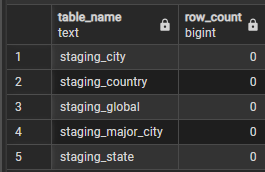

Kết quả truy vấn hiển thị năm dòng tương ứng với `staging_global`, `staging_country`, `staging_state`, `staging_city` và `staging_major_city`. Việc truy vấn thực hiện thành công trên cả năm bảng chứng minh các staging tables đã được tạo và có thể được truy cập trong database hiện tại.

Tất cả giá trị `row_count` đều bằng `0`, đúng với trạng thái mong đợi ngay sau khi tạo bảng và trước khi import CSV.

Phép kiểm tra này mới xác nhận sự tồn tại và số lượng bản ghi của các bảng, chưa xác minh chi tiết tên cột, kiểu dữ liệu hoặc constraint. Những nội dung đó được xác định bởi các câu lệnh `CREATE TABLE` ở Mục 5.1–5.5, còn tính đầy đủ của dữ liệu sẽ được đánh giá lại bằng row count và các truy vấn validation sau khi import.

## 6. Import 5 CSV vào staging bằng COPY

Mục này sử dụng lệnh `COPY` của PostgreSQL để nạp lần lượt năm file CSV vào các staging tables đã tạo ở Mục 5. Các lệnh cần được chạy trong **Query Tool của database `climate_db`**, sau khi Mục 5.6 xác nhận cả năm bảng đang rỗng.

Danh sách cột được khai báo rõ trong từng lệnh để khớp đúng thứ tự cột của CSV. Hai cột do PostgreSQL quản lý không xuất hiện trong danh sách import: `staging_id` tự tăng bằng sequence và `loaded_at` nhận thời điểm nạp từ giá trị mặc định. Các tùy chọn chung có ý nghĩa như sau:

- `FORMAT CSV`: đọc dữ liệu theo định dạng CSV.
- `HEADER TRUE`: bỏ qua dòng tiêu đề đầu tiên.
- `DELIMITER ','`: dùng dấu phẩy để phân tách các trường.
- `QUOTE` và `ESCAPE` bằng dấu nháy kép: đọc đúng chuỗi có dấu phẩy hoặc dấu nháy bên trong.
- `NULL ''`: chuyển trường trống thành giá trị SQL `NULL`.
- `ENCODING 'UTF8'`: đọc file bằng mã hóa UTF-8.

### 6.1. Import `GlobalTemperatures.csv` vào `staging_global`

In [ ]:
COPY staging_global (
    dt,
    land_average_temperature,
    land_average_temperature_uncertainty,
    land_max_temperature,
    land_max_temperature_uncertainty,
    land_min_temperature,
    land_min_temperature_uncertainty,
    land_and_ocean_average_temperature,
    land_and_ocean_average_temperature_uncertainty
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalTemperatures.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` ánh xạ chín cột của `GlobalTemperatures.csv` vào các cột ngày, nhiệt độ và độ bất định của `staging_global`. PostgreSQL tự sinh `staging_id` và tự gán `loaded_at` cho mỗi bản ghi.

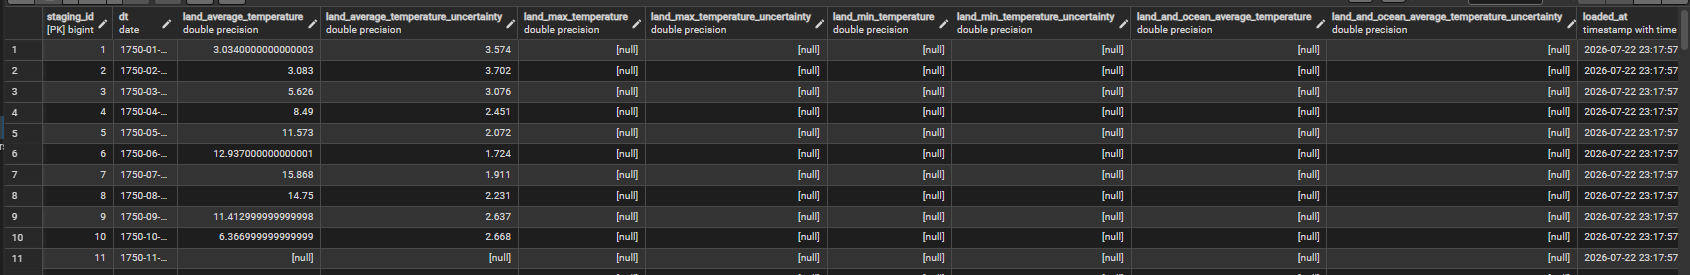

### 6.2. Import `GlobalLandTemperaturesByCountry.csv` vào `staging_country`

In [ ]:
COPY staging_country (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    country
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByCountry.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh này nạp ngày quan sát, nhiệt độ trung bình, độ bất định và tên quốc gia từ `GlobalLandTemperaturesByCountry.csv` vào `staging_country`. Dữ liệu tên quốc gia được giữ nguyên như nguồn, chưa chuẩn hóa hoặc làm sạch ở staging layer.

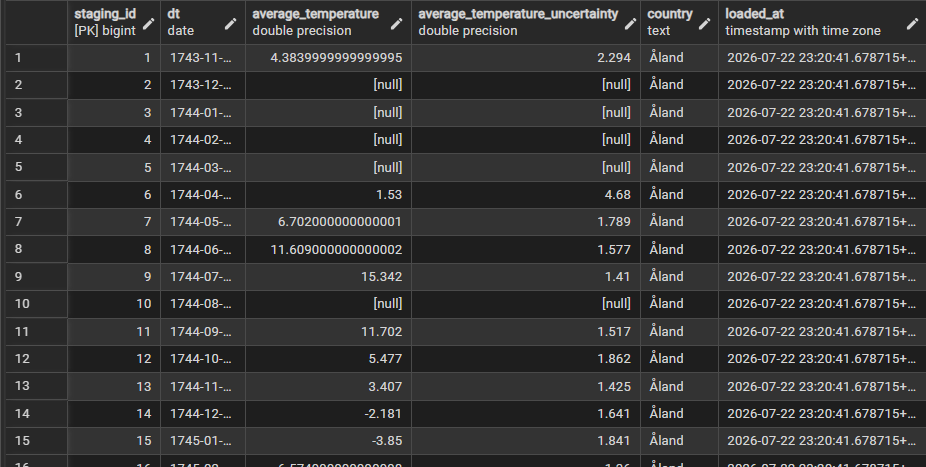

### 6.3. Import `GlobalLandTemperaturesByState.csv` vào `staging_state`

In [ ]:
COPY staging_state (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    state,
    country
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByState.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` nạp năm trường của `GlobalLandTemperaturesByState.csv` vào `staging_state`, trong đó `state` luôn đi cùng `country` để bảo toàn đầy đủ ngữ cảnh địa lý của mỗi quan sát. Các trường nhiệt độ trống trong CSV được chuyển thành `NULL`.

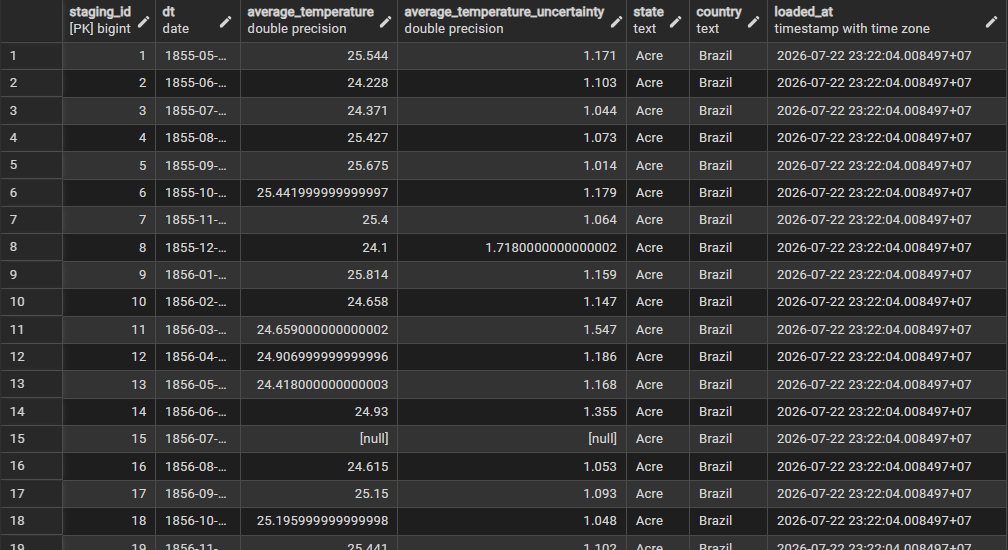

### 6.4. Import `GlobalLandTemperaturesByCity.csv` vào `staging_city`

In [ ]:
COPY staging_city (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    city,
    country,
    latitude,
    longitude
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByCity.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh này nạp dữ liệu thành phố gồm ngày, nhiệt độ, độ bất định, tên thành phố, quốc gia, vĩ độ và kinh độ vào `staging_city`. Tọa độ được nhập dưới dạng `TEXT` để giữ nguyên các ký hiệu hướng `N`, `S`, `E`, `W`; việc chuyển thành số có dấu được thực hiện ở analytical layer.

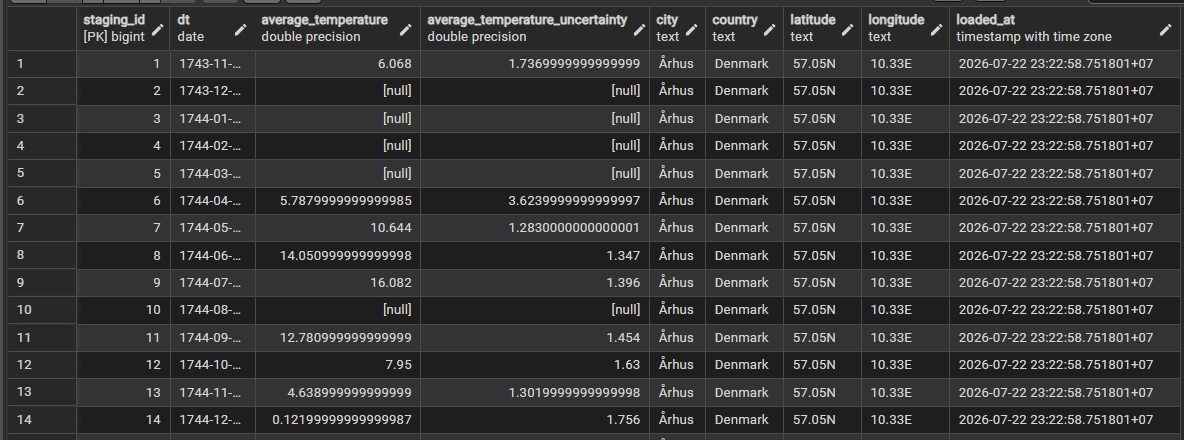

### 6.5. Import `GlobalLandTemperaturesByMajorCity.csv` vào `staging_major_city`

In [ ]:
COPY staging_major_city (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    city,
    country,
    latitude,
    longitude
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByMajorCity.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` cuối cùng nạp dữ liệu của các thành phố lớn vào `staging_major_city`. Mặc dù có cấu trúc gần giống dữ liệu City, dataset này được lưu trong bảng riêng để giữ đúng phạm vi nguồn và hỗ trợ truy vết độc lập.

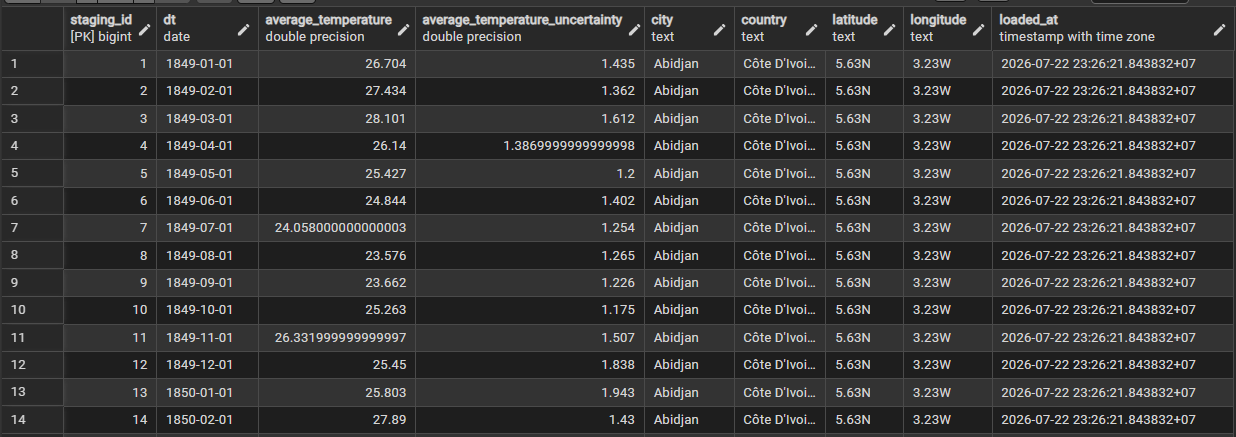

## 7. Kiểm tra dữ liệu sau import

Mục này kiểm tra dữ liệu ngay sau khi năm CSV nguyên bản được import vào staging layer và **trước khi thực hiện cắt dữ liệu ở Mục 8**. Ba nhóm kiểm tra lần lượt đối chiếu số dòng, xác nhận schema/primary key và phát hiện duplicate theo grain nghiệp vụ.

### 7.1. Đối chiếu số dòng và metadata nạp dữ liệu

In [ ]:
WITH expected(dataset, expected_rows) AS (
    VALUES
        ('global', 3192::BIGINT),
        ('country', 577462::BIGINT),
        ('state', 645675::BIGINT),
        ('city', 8599212::BIGINT), -- Dữ liệu City nguyên bản, trước khi cắt ở Mục 8.
        ('major_city', 239177::BIGINT)
),
actual(dataset, actual_rows, min_staging_id, max_staging_id, null_loaded_at) AS (
    SELECT
        'global',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_global
    UNION ALL
    SELECT
        'country',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_country
    UNION ALL
    SELECT
        'state',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_state
    UNION ALL
    SELECT
        'city',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_city
    UNION ALL
    SELECT
        'major_city',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_major_city
)
SELECT
    e.dataset,
    e.expected_rows,
    a.actual_rows,
    a.actual_rows - e.expected_rows AS difference,
    a.min_staging_id,
    a.max_staging_id,
    a.null_loaded_at,
    CASE
        WHEN a.actual_rows = e.expected_rows
         AND a.min_staging_id = 1
         AND a.max_staging_id = a.actual_rows
         AND a.null_loaded_at = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM expected AS e
JOIN actual AS a USING (dataset)
ORDER BY e.dataset;


Truy vấn sử dụng CTE `expected` để khai báo số dòng mong đợi của năm CSV nguyên bản và CTE `actual` để tính số dòng thực tế trong từng staging table.

Ngoài row count, truy vấn còn kiểm tra `staging_id` nhỏ nhất bằng `1`, `staging_id` lớn nhất bằng tổng số dòng và không có `loaded_at` bị `NULL`. Cột `difference` cho biết chênh lệch giữa thực tế và mong đợi. Trạng thái chỉ là `PASS` khi đồng thời thỏa mãn đầy đủ các điều kiện về số dòng, dải ID và thời điểm nạp.

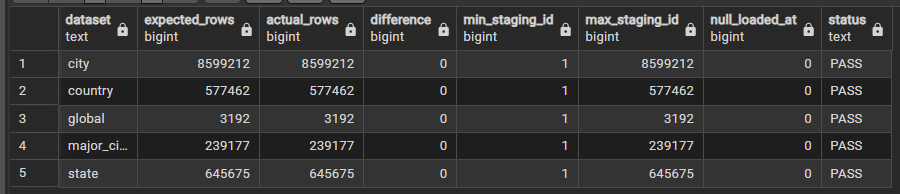

Kết quả cho thấy cả năm dataset đều có trạng thái `PASS` và `difference = 0`. Số dòng thực tế lần lượt là Global 3.192, Country 577.462, State 645.675, City 8.599.212 và Major City 239.177, hoàn toàn khớp với số dòng mong đợi trước bước cắt.

Ở mỗi bảng, `min_staging_id = 1`, `max_staging_id = actual_rows` và `null_loaded_at = 0`. Điều này xác nhận dữ liệu đã được import đầy đủ trong lần nạp hiện tại, dải khóa staging liên tục và tất cả bản ghi đều có thời điểm nạp.

### 7.2. Kiểm tra schema và primary key của staging tables

In [ ]:
-- Kiểm tra kiểu dữ liệu của 5 staging tables.
SELECT
    table_name,
    ordinal_position,
    column_name,
    data_type,
    is_nullable,
    column_default
FROM information_schema.columns
WHERE table_schema = 'public'
  AND table_name IN (
      'staging_global',
      'staging_country',
      'staging_state',
      'staging_city',
      'staging_major_city'
  )
ORDER BY table_name, ordinal_position;

-- Kiểm tra primary key của staging tables.
SELECT
    tc.table_name,
    tc.constraint_name,
    kcu.column_name
FROM information_schema.table_constraints AS tc
JOIN information_schema.key_column_usage AS kcu
  ON kcu.constraint_schema = tc.constraint_schema
 AND kcu.constraint_name = tc.constraint_name
WHERE tc.table_schema = 'public'
  AND tc.constraint_type = 'PRIMARY KEY'
  AND tc.table_name LIKE 'staging_%'
ORDER BY tc.table_name;


Cell gồm hai truy vấn đọc metadata hệ thống của PostgreSQL. Truy vấn thứ nhất đọc `information_schema.columns` để liệt kê tên bảng, vị trí cột, tên cột, kiểu dữ liệu, khả năng nhận `NULL` và giá trị mặc định của năm staging tables. Kết quả này dùng để đối chiếu cấu trúc thực tế với các lệnh `CREATE TABLE` ở Mục 5.

Truy vấn thứ hai kết hợp `information_schema.table_constraints` với `information_schema.key_column_usage` để tìm các constraint loại `PRIMARY KEY`. Mỗi staging table phải có đúng một primary key trên cột `staging_id`, giúp định danh duy nhất và duy trì data lineage cho các bước sau.

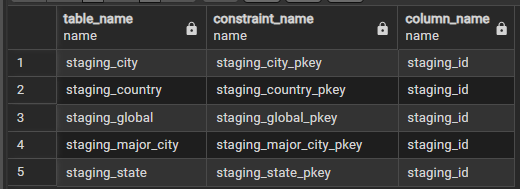

Ảnh kết quả hiển thị đúng năm staging tables. Mỗi bảng có một constraint primary key với tên tương ứng như `staging_city_pkey`, `staging_country_pkey` và đều sử dụng cột `staging_id`. Vì vậy, phần kiểm tra primary key đạt yêu cầu.

Do cell chứa hai câu `SELECT`, pgAdmin đang hiển thị Data Output của câu truy vấn cuối cùng, tức kết quả primary key. Ảnh này chưa thể hiện danh sách cột và kiểu dữ liệu từ truy vấn đầu tiên. Khi cần lưu bằng chứng kiểm tra schema, hãy chạy riêng câu `SELECT` từ `information_schema.columns` và chụp kết quả của truy vấn đó.

### 7.3. Kiểm tra duplicate theo grain nghiệp vụ

In [ ]:
-- Duplicate theo grain nghiệp vụ; giá trị 0 là kết quả mong đợi.
SELECT
    'global' AS dataset,
    COUNT(*) - COUNT(DISTINCT (dt)) AS duplicate_business_keys
FROM staging_global
UNION ALL
SELECT
    'country',
    COUNT(*) - COUNT(DISTINCT (dt, country))
FROM staging_country
UNION ALL
SELECT
    'state',
    COUNT(*) - COUNT(DISTINCT (dt, state, country))
FROM staging_state
UNION ALL
SELECT
    'city',
    COUNT(*) - COUNT(DISTINCT (dt, city, country, latitude, longitude))
FROM staging_city
UNION ALL
SELECT
    'major_city',
    COUNT(*) - COUNT(DISTINCT (dt, city, country, latitude, longitude))
FROM staging_major_city
ORDER BY dataset;


Truy vấn xác định số bản ghi trùng bằng cách lấy tổng số dòng trừ số tổ hợp khóa nghiệp vụ phân biệt. Khóa được chọn theo grain của từng dataset: Global dùng `dt`; Country dùng `dt, country`; State dùng `dt, state, country`; City và Major City dùng `dt, city, country, latitude, longitude`.

Cột `duplicate_business_keys` biểu thị số dòng dư thừa so với các tổ hợp khóa duy nhất. Kết quả mong đợi là `0` cho cả năm dataset. Kiểm tra này chỉ phát hiện trùng theo grain đã định nghĩa và không thay thế các kiểm tra missing values hoặc chuẩn hóa tên địa lý ở Notebook 03.

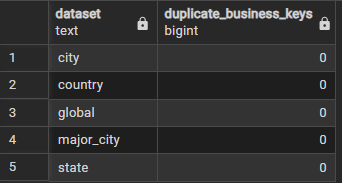

Kết quả cho thấy `duplicate_business_keys = 0` ở cả Global, Country, State, City và Major City. Như vậy, không có bản ghi lặp theo grain nghiệp vụ đã xác định trong dữ liệu staging sau import.

Kết hợp với trạng thái `PASS` của Mục 7.1 và primary key hợp lệ ở Mục 7.2, staging layer đã đạt các điều kiện kiểm tra ban đầu về số lượng, khả năng truy vết và tính duy nhất. Dữ liệu có thể chuyển sang bước cắt City tại Mục 8 trước khi xây dựng analytical layer và bàn giao cho Notebook 03.

## 8. Tiến hành cắt dữ liệu file `GlobalLandTemperaturesByCity.csv`

Mục này cắt dữ liệu **trực tiếp trên `staging_city`** theo hai bước: chỉ giữ lại khoảng một nửa số quốc gia có trong dữ liệu, sau đó chỉ giữ thời gian từ `1863-01-01` đến trước `2014-01-01`. Các dòng thiếu nhiệt độ vẫn được giữ lại để Notebook 03 xử lý theo đúng trách nhiệm data cleaning.

Sau mỗi lệnh `DELETE`, một khối validation chạy ngay trong transaction. Nếu số dòng hoặc số quốc gia không đúng, PostgreSQL phát sinh exception để ngăn `COMMIT`; khi đó cần chạy `ROLLBACK;`. Sau khi commit thành công, `staging_city` chỉ còn 5.010.113 dòng và được dùng trực tiếp từ Mục 9 trở đi. Thao tác này không thể hoàn tác sau `COMMIT` nếu không import lại CSV nguyên bản, vì vậy chỉ chạy sau khi Mục 7 đã đạt yêu cầu.

### 8.1. Cắt theo tên quốc gia

#### 8.1.1. Kiểm tra số quốc gia có trong dữ liệu

In [ ]:
-- Danh sách 20 quốc gia lớn/bắt buộc theo yêu cầu của bước cắt dữ liệu.
WITH mandatory_countries(country) AS (
    VALUES
        ('Vietnam'), ('United States'), ('China'), ('India'), ('Russia'),
        ('Brazil'), ('Japan'), ('Germany'), ('United Kingdom'), ('France'),
        ('Canada'), ('Australia'), ('Italy'), ('South Korea'), ('Mexico'),
        ('Indonesia'), ('Turkey'), ('Saudi Arabia'), ('Spain'), ('South Africa')
),
source_countries AS (
    SELECT DISTINCT country
    FROM staging_city
    WHERE NULLIF(BTRIM(country), '') IS NOT NULL
),
source_stats AS (
    SELECT
        COUNT(*) AS source_rows,
        COUNT(*) FILTER (
            WHERE NULLIF(BTRIM(country), '') IS NULL
        ) AS invalid_country_rows
    FROM staging_city
)
SELECT
    s.source_rows,
    (SELECT COUNT(*) FROM source_countries) AS distinct_countries,
    s.invalid_country_rows,
    (
        SELECT COUNT(*)
        FROM mandatory_countries AS m
        JOIN source_countries AS c USING (country)
    ) AS mandatory_countries_found,
    ARRAY(
        SELECT m.country
        FROM mandatory_countries AS m
        LEFT JOIN source_countries AS c USING (country)
        WHERE c.country IS NULL
        ORDER BY m.country
    ) AS missing_mandatory_countries
FROM source_stats AS s;

Truy vấn kiểm tra quy mô và độ phủ quốc gia của dữ liệu City nguyên bản trước khi thực hiện lọc. `invalid_country_rows` đếm các dòng có quốc gia `NULL` hoặc chuỗi rỗng.

Hai cột cuối xác minh đầy đủ 20 quốc gia bắt buộc: `mandatory_countries_found` phải bằng `20` và `missing_mandatory_countries` phải là mảng rỗng `{}`. Nếu thiếu bất kỳ quốc gia nào, không nên chạy Mục 8.1.2 vì tập kết quả sẽ không đáp ứng tiêu chí lựa chọn ban đầu.

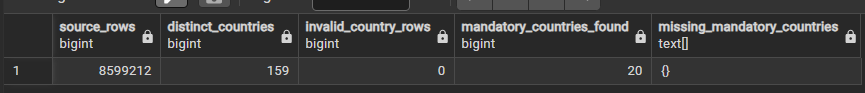

Nhận xét kết quả

#### 8.1.2. Cắt dữ liệu giữ lại 80 quốc gia

In [ ]:
BEGIN;

-- Tạo lại manifest quốc gia dùng cho thao tác cắt trực tiếp.
DROP TABLE IF EXISTS city_target_countries;

-- Lưu cố định 80 quốc gia để kết quả không thay đổi giữa các lần chạy.
CREATE TABLE city_target_countries (
    country TEXT PRIMARY KEY,
    selection_group TEXT NOT NULL CHECK (
        selection_group IN ('mandatory', 'additional')
    )
);

INSERT INTO city_target_countries (country, selection_group)
VALUES
    ('Vietnam', 'mandatory'),
    ('United States', 'mandatory'),
    ('China', 'mandatory'),
    ('India', 'mandatory'),
    ('Russia', 'mandatory'),
    ('Brazil', 'mandatory'),
    ('Japan', 'mandatory'),
    ('Germany', 'mandatory'),
    ('United Kingdom', 'mandatory'),
    ('France', 'mandatory'),
    ('Canada', 'mandatory'),
    ('Australia', 'mandatory'),
    ('Italy', 'mandatory'),
    ('South Korea', 'mandatory'),
    ('Mexico', 'mandatory'),
    ('Indonesia', 'mandatory'),
    ('Turkey', 'mandatory'),
    ('Saudi Arabia', 'mandatory'),
    ('Spain', 'mandatory'),
    ('South Africa', 'mandatory'),
    ('Algeria', 'additional'),
    ('Angola', 'additional'),
    ('Azerbaijan', 'additional'),
    ('Bahrain', 'additional'),
    ('Bangladesh', 'additional'),
    ('Bolivia', 'additional'),
    ('Botswana', 'additional'),
    ('Burundi', 'additional'),
    ('Cameroon', 'additional'),
    ('Chad', 'additional'),
    ('Colombia', 'additional'),
    ('Congo (Democratic Republic Of The)', 'additional'),
    ('Costa Rica', 'additional'),
    ('Denmark', 'additional'),
    ('Djibouti', 'additional'),
    ('Ecuador', 'additional'),
    ('El Salvador', 'additional'),
    ('Eritrea', 'additional'),
    ('Finland', 'additional'),
    ('Gabon', 'additional'),
    ('Ghana', 'additional'),
    ('Guinea Bissau', 'additional'),
    ('Haiti', 'additional'),
    ('Iran', 'additional'),
    ('Iraq', 'additional'),
    ('Kazakhstan', 'additional'),
    ('Laos', 'additional'),
    ('Lebanon', 'additional'),
    ('Lesotho', 'additional'),
    ('Libya', 'additional'),
    ('Lithuania', 'additional'),
    ('Macedonia', 'additional'),
    ('Madagascar', 'additional'),
    ('Malaysia', 'additional'),
    ('Mauritius', 'additional'),
    ('Moldova', 'additional'),
    ('Mozambique', 'additional'),
    ('New Zealand', 'additional'),
    ('Nicaragua', 'additional'),
    ('Norway', 'additional'),
    ('Oman', 'additional'),
    ('Panama', 'additional'),
    ('Poland', 'additional'),
    ('Romania', 'additional'),
    ('Rwanda', 'additional'),
    ('Serbia', 'additional'),
    ('Sierra Leone', 'additional'),
    ('Slovakia', 'additional'),
    ('Slovenia', 'additional'),
    ('Sudan', 'additional'),
    ('Swaziland', 'additional'),
    ('Switzerland', 'additional'),
    ('Syria', 'additional'),
    ('Togo', 'additional'),
    ('Turkmenistan', 'additional'),
    ('Ukraine', 'additional'),
    ('Uruguay', 'additional'),
    ('Uzbekistan', 'additional'),
    ('Yemen', 'additional'),
    ('Zambia', 'additional');

-- Dừng transaction nếu danh sách không có đúng 20 + 60 quốc gia.
DO $$
DECLARE
    total_count INTEGER;
    mandatory_count INTEGER;
BEGIN
    SELECT
        COUNT(*),
        COUNT(*) FILTER (WHERE selection_group = 'mandatory')
    INTO total_count, mandatory_count
    FROM city_target_countries;

    IF total_count <> 80 OR mandatory_count <> 20 THEN
        RAISE EXCEPTION
            'Danh sách mục tiêu không hợp lệ: tổng %, bắt buộc %.',
            total_count, mandatory_count;
    END IF;
END
$$;

-- Xóa trực tiếp các dòng không thuộc danh sách 80 quốc gia.
DELETE FROM staging_city AS s
WHERE NOT EXISTS (
    SELECT 1
    FROM city_target_countries AS t
    WHERE t.country = s.country
);

-- Không cho phép commit nếu kết quả lọc quốc gia sai data contract.
DO $$
DECLARE
    remaining_rows BIGINT;
    remaining_countries INTEGER;
    mandatory_retained INTEGER;
BEGIN
    SELECT COUNT(*), COUNT(DISTINCT country)
    INTO remaining_rows, remaining_countries
    FROM staging_city;

    SELECT COUNT(DISTINCT s.country)
    INTO mandatory_retained
    FROM staging_city AS s
    JOIN city_target_countries AS t USING (country)
    WHERE t.selection_group = 'mandatory';

    IF remaining_rows <> 6907065
       OR remaining_countries <> 80
       OR mandatory_retained <> 20 THEN
        RAISE EXCEPTION
            'Lọc quốc gia sai data contract: rows %, countries %, mandatory %.',
            remaining_rows, remaining_countries, mandatory_retained;
    END IF;
END
$$;

COMMIT;

ANALYZE staging_city;

-- Kiểm tra kết quả sau khi chỉ lọc theo quốc gia.
SELECT
    COUNT(*) AS rows_after_country_filter,
    COUNT(DISTINCT country) AS selected_countries,
    COUNT(DISTINCT country) FILTER (
        WHERE country IN (
            SELECT country
            FROM city_target_countries
            WHERE selection_group = 'mandatory'
        )
    ) AS mandatory_countries_retained,
    MIN(dt) AS min_date,
    MAX(dt) AS max_date,
    COUNT(*) FILTER (WHERE average_temperature IS NULL)
        AS missing_temperature_rows,
    CASE
        WHEN COUNT(*) = 6907065
         AND COUNT(DISTINCT country) = 80
         AND COUNT(DISTINCT country) FILTER (
             WHERE country IN (
                 SELECT country
                 FROM city_target_countries
                 WHERE selection_group = 'mandatory'
             )
         ) = 20
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM staging_city;

Cell tạo bảng `city_target_countries` như một manifest cố định thay cho `ORDER BY RANDOM()`. Hai nhãn `mandatory` và `additional` giúp chứng minh danh sách gồm đúng 20 quốc gia bắt buộc và 60 quốc gia bổ sung. Khối `DO` dừng transaction nếu số lượng này bị thay đổi ngoài ý muốn.

Sau đó, `DELETE ... WHERE NOT EXISTS` xóa trực tiếp khỏi `staging_city` các dòng không thuộc manifest. Kết quả mong đợi là 6.907.065 dòng còn lại, 80 quốc gia, đủ 20 quốc gia bắt buộc, thời gian từ `1743-11-01` đến `2013-09-01` và trạng thái `PASS`. `missing_temperature_rows` không cần bằng 0 vì Mục 8 chưa thực hiện data cleaning.

Các `staging_id` còn lại vẫn giữ giá trị ban đầu nên có thể xuất hiện khoảng trống sau `DELETE`; điều này là bình thường và giúp duy trì data lineage về lần import gốc. Nếu validation phát sinh exception, transaction chưa được commit và cần chạy `ROLLBACK;` trước khi sửa nguyên nhân hoặc thử lại.

### 8.2. Cắt theo giai đoạn thời gian 1863–2013

#### 8.2.1. Kiểm tra dải thời gian

In [ ]:
-- Đánh giá dải thời gian trước khi tạo bảng City cuối cùng.
SELECT
    COUNT(*) AS rows_before_time_filter,
    MIN(dt) AS min_date_before_filter,
    MAX(dt) AS max_date_before_filter,
    COUNT(DISTINCT dt) AS distinct_dates_before_filter,
    COUNT(*) FILTER (
        WHERE dt >= DATE '1863-01-01'
          AND dt < DATE '2014-01-01'
    ) AS rows_in_target_period,
    COUNT(*) FILTER (
        WHERE dt < DATE '1863-01-01'
           OR dt >= DATE '2014-01-01'
    ) AS rows_outside_target_period,
    COUNT(*) FILTER (WHERE dt IS NULL) AS null_date_rows
FROM staging_city;

Truy vấn chưa xóa thêm dữ liệu mà chỉ đo phạm vi thời gian của `staging_city` sau bước lọc quốc gia. Kết quả mong đợi gồm 6.907.065 dòng, 3.239 tháng phân biệt, ngày nhỏ nhất `1743-11-01`, ngày lớn nhất `2013-09-01` và không có `dt` bị `NULL`.

Khoảng lọc được biểu diễn theo dạng nửa mở: từ `1863-01-01` trở đi và nhỏ hơn `2014-01-01`. Cách viết này bao phủ toàn bộ năm 2013 mà không phụ thuộc ngày cuối tháng. Dự kiến có 5.010.113 dòng nằm trong giai đoạn mục tiêu và 1.896.952 dòng nằm trước năm 1863 cần xóa trực tiếp ở Mục 8.2.2.

#### 8.2.2. Tạo tập City cuối trong giai đoạn 1863–2013

In [ ]:
BEGIN;

-- Xóa trực tiếp các dòng nằm ngoài giai đoạn mục tiêu.
DELETE FROM staging_city
WHERE dt < DATE '1863-01-01'
   OR dt >= DATE '2014-01-01'
   OR dt IS NULL;

-- Không cho phép commit nếu kết quả cuối sai data contract.
DO $$
DECLARE
    checked_rows BIGINT;
    checked_countries BIGINT;
    checked_dates BIGINT;
    checked_min_date DATE;
    checked_max_date DATE;
    checked_missing_temperature BIGINT;
    checked_invalid_dates BIGINT;
BEGIN
    SELECT
        COUNT(*),
        COUNT(DISTINCT country),
        COUNT(DISTINCT dt),
        MIN(dt),
        MAX(dt),
        COUNT(*) FILTER (WHERE average_temperature IS NULL),
        COUNT(*) FILTER (
            WHERE dt < DATE '1863-01-01'
               OR dt >= DATE '2014-01-01'
               OR dt IS NULL
        )
    INTO
        checked_rows,
        checked_countries,
        checked_dates,
        checked_min_date,
        checked_max_date,
        checked_missing_temperature,
        checked_invalid_dates
    FROM staging_city;

    IF checked_rows <> 5010113
       OR checked_countries <> 80
       OR checked_dates <> 1809
       OR checked_min_date <> DATE '1863-01-01'
       OR checked_max_date <> DATE '2013-09-01'
       OR checked_missing_temperature <> 43101
       OR checked_invalid_dates <> 0 THEN
        RAISE EXCEPTION
            'Cắt thời gian sai data contract: rows %, countries %, dates %, min %, max %, missing %, invalid %.',
            checked_rows, checked_countries, checked_dates,
            checked_min_date, checked_max_date,
            checked_missing_temperature, checked_invalid_dates;
    END IF;
END
$$;

COMMIT;

ANALYZE staging_city;

-- Xác nhận data contract cuối của bước cắt dữ liệu.
WITH validation AS (
    SELECT
        COUNT(*) AS final_rows,
        COUNT(DISTINCT country) AS final_countries,
        COUNT(DISTINCT dt) AS final_distinct_dates,
        MIN(dt) AS final_min_date,
        MAX(dt) AS final_max_date,
        COUNT(*) FILTER (WHERE average_temperature IS NULL)
            AS missing_temperature_rows,
        COUNT(*) FILTER (
            WHERE dt < DATE '1863-01-01'
               OR dt >= DATE '2014-01-01'
               OR dt IS NULL
        ) AS invalid_date_rows
    FROM staging_city
)
SELECT
    final_rows,
    final_countries,
    final_distinct_dates,
    final_min_date,
    final_max_date,
    missing_temperature_rows,
    invalid_date_rows,
    CASE
        WHEN final_rows = 5010113
         AND final_countries = 80
         AND final_distinct_dates = 1809
         AND final_min_date = DATE '1863-01-01'
         AND final_max_date = DATE '2013-09-01'
         AND missing_temperature_rows = 43101
         AND invalid_date_rows = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation;

Cell dùng `DELETE` trực tiếp trên `staging_city` để loại các dòng trước `1863-01-01`, từ `2014-01-01` trở đi hoặc có ngày bị `NULL`. Các cột nhiệt độ bị `NULL` không nằm trong điều kiện xóa nên vẫn được bảo toàn. Primary key `staging_id` và các giá trị ID gốc không bị tạo lại; sau khi xóa, việc ID có khoảng trống là kết quả bình thường.

Khối validation được chạy trước `COMMIT`; nếu bất kỳ chỉ số nào không đúng, transaction chuyển sang trạng thái lỗi và cần `ROLLBACK;`, nhờ đó thay đổi chưa được lưu vĩnh viễn. Kết quả đạt yêu cầu khi `staging_city` có 5.010.113 dòng, 80 quốc gia, 1.809 tháng phân biệt, ngày nhỏ nhất `1863-01-01`, ngày lớn nhất `2013-09-01`, `invalid_date_rows = 0` và trạng thái `PASS`. Có 43.101 dòng thiếu `average_temperature` vẫn được giữ nguyên cho Notebook 03.

Cụm từ “150 năm” trong bước cắt cũ là cách gọi gần đúng. Khoảng từ đầu năm 1863 đến hết năm 2013 bao phủ 151 nhãn năm theo cách đếm bao gồm hai đầu; dữ liệu thực tế kết thúc ở tháng 09/2013 nên có 1.809 tháng, tương đương 150 năm và 9 tháng quan sát. Sau khi `COMMIT` thành công, muốn khôi phục 8.599.212 dòng nguyên bản phải tạo lại `staging_city` và import lại CSV ở Mục 6.

## 9. Chuẩn hóa và nạp dimension/fact

Global, Country, State và Major City đọc từ staging tables sau import. Riêng `staging_city` đã được cắt trực tiếp và kiểm tra ở Mục 8, vì vậy bảng này chứa 5.010.113 dòng thuộc 80 quốc gia trong giai đoạn 1863–2013. Mục này tạo analytical layer theo mô hình sao:

- Dimensions: date, country, state, city.
- Facts: global, country, state, city, major city.
- Tọa độ N/S/E/W được chuyển thành số có dấu.
- source_staging_id được giữ trong mọi fact.

Cell DDL có cơ chế DROP ... CASCADE và sẽ tạo lại analytical layer. Sau đó chạy lần lượt cell nạp dimensions, cell nạp facts và cell validation.


In [ ]:
BEGIN;

DROP TABLE IF EXISTS fact_major_city_temperature CASCADE;
DROP TABLE IF EXISTS fact_city_temperature CASCADE;
DROP TABLE IF EXISTS fact_state_temperature CASCADE;
DROP TABLE IF EXISTS fact_country_temperature CASCADE;
DROP TABLE IF EXISTS fact_global_temperature CASCADE;
DROP TABLE IF EXISTS dim_city CASCADE;
DROP TABLE IF EXISTS dim_state CASCADE;
DROP TABLE IF EXISTS dim_country CASCADE;
DROP TABLE IF EXISTS dim_date CASCADE;

CREATE TABLE dim_date (
    date_id BIGSERIAL PRIMARY KEY,
    full_date DATE NOT NULL UNIQUE,
    year SMALLINT NOT NULL,
    month SMALLINT NOT NULL CHECK (month BETWEEN 1 AND 12),
    quarter SMALLINT NOT NULL CHECK (quarter BETWEEN 1 AND 4),
    decade SMALLINT NOT NULL
);

CREATE TABLE dim_country (
    country_id BIGSERIAL PRIMARY KEY,
    country_name TEXT NOT NULL UNIQUE,
    CHECK (BTRIM(country_name) <> '')
);

CREATE TABLE dim_state (
    state_id BIGSERIAL PRIMARY KEY,
    state_name TEXT NOT NULL,
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    UNIQUE (state_name, country_id),
    CHECK (BTRIM(state_name) <> '')
);

CREATE TABLE dim_city (
    city_id BIGSERIAL PRIMARY KEY,
    city_name TEXT NOT NULL,
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    latitude DOUBLE PRECISION NOT NULL CHECK (latitude BETWEEN -90 AND 90),
    longitude DOUBLE PRECISION NOT NULL CHECK (longitude BETWEEN -180 AND 180),
    is_major_city BOOLEAN NOT NULL DEFAULT FALSE,
    UNIQUE (city_name, country_id, latitude, longitude),
    CHECK (BTRIM(city_name) <> '')
);

CREATE TABLE fact_global_temperature (
    global_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    land_average_temperature DOUBLE PRECISION,
    land_average_temperature_uncertainty DOUBLE PRECISION,
    land_max_temperature DOUBLE PRECISION,
    land_max_temperature_uncertainty DOUBLE PRECISION,
    land_min_temperature DOUBLE PRECISION,
    land_min_temperature_uncertainty DOUBLE PRECISION,
    land_and_ocean_average_temperature DOUBLE PRECISION,
    land_and_ocean_average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id)
);

CREATE TABLE fact_country_temperature (
    country_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, country_id)
);

CREATE TABLE fact_state_temperature (
    state_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    state_id BIGINT NOT NULL REFERENCES dim_state(state_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, state_id)
);

CREATE TABLE fact_city_temperature (
    city_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    city_id BIGINT NOT NULL REFERENCES dim_city(city_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, city_id)
);

CREATE TABLE fact_major_city_temperature (
    major_city_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    city_id BIGINT NOT NULL REFERENCES dim_city(city_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, city_id)
);

COMMIT;


In [ ]:
BEGIN;

INSERT INTO dim_date (full_date, year, month, quarter, decade)
SELECT
    full_date,
    EXTRACT(YEAR FROM full_date)::SMALLINT,
    EXTRACT(MONTH FROM full_date)::SMALLINT,
    EXTRACT(QUARTER FROM full_date)::SMALLINT,
    ((EXTRACT(YEAR FROM full_date)::INTEGER / 10) * 10)::SMALLINT
FROM (
    SELECT dt AS full_date FROM staging_global WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_country WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_state WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_city WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_major_city WHERE dt IS NOT NULL
) AS source_dates
ORDER BY full_date;

INSERT INTO dim_country (country_name)
SELECT country_name
FROM (
    SELECT NULLIF(BTRIM(country), '') AS country_name FROM staging_country
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_state
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_city
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_major_city
) AS source_countries
WHERE country_name IS NOT NULL
ORDER BY country_name;

INSERT INTO dim_state (state_name, country_id)
SELECT DISTINCT BTRIM(s.state), c.country_id
FROM staging_state AS s
JOIN dim_country AS c
  ON c.country_name = BTRIM(s.country)
WHERE NULLIF(BTRIM(s.state), '') IS NOT NULL
ORDER BY BTRIM(s.state), c.country_id;

WITH city_source AS (
    SELECT
        NULLIF(BTRIM(s.city), '') AS city_name,
        NULLIF(BTRIM(s.country), '') AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude,
        FALSE AS is_major_city
    FROM staging_city AS s

    UNION ALL

    SELECT
        NULLIF(BTRIM(s.city), ''),
        NULLIF(BTRIM(s.country), ''),
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END,
        TRUE
    FROM staging_major_city AS s
)
INSERT INTO dim_city (
    city_name,
    country_id,
    latitude,
    longitude,
    is_major_city
)
SELECT
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude,
    BOOL_OR(cs.is_major_city)
FROM city_source AS cs
JOIN dim_country AS c
  ON c.country_name = cs.country_name
WHERE cs.city_name IS NOT NULL
  AND cs.country_name IS NOT NULL
  AND cs.latitude IS NOT NULL
  AND cs.longitude IS NOT NULL
GROUP BY
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude
ORDER BY
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude;

COMMIT;


In [ ]:
BEGIN;

INSERT INTO fact_global_temperature (
    date_id,
    source_staging_id,
    land_average_temperature,
    land_average_temperature_uncertainty,
    land_max_temperature,
    land_max_temperature_uncertainty,
    land_min_temperature,
    land_min_temperature_uncertainty,
    land_and_ocean_average_temperature,
    land_and_ocean_average_temperature_uncertainty
)
SELECT
    d.date_id,
    s.staging_id,
    s.land_average_temperature,
    s.land_average_temperature_uncertainty,
    s.land_max_temperature,
    s.land_max_temperature_uncertainty,
    s.land_min_temperature,
    s.land_min_temperature_uncertainty,
    s.land_and_ocean_average_temperature,
    s.land_and_ocean_average_temperature_uncertainty
FROM staging_global AS s
JOIN dim_date AS d ON d.full_date = s.dt;

INSERT INTO fact_country_temperature (
    date_id,
    country_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    c.country_id,
    s.staging_id,
    s.average_temperature,
    s.average_temperature_uncertainty
FROM staging_country AS s
JOIN dim_date AS d ON d.full_date = s.dt
JOIN dim_country AS c ON c.country_name = BTRIM(s.country);

INSERT INTO fact_state_temperature (
    date_id,
    state_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    st.state_id,
    s.staging_id,
    s.average_temperature,
    s.average_temperature_uncertainty
FROM staging_state AS s
JOIN dim_date AS d ON d.full_date = s.dt
JOIN dim_country AS c ON c.country_name = BTRIM(s.country)
JOIN dim_state AS st
  ON st.country_id = c.country_id
 AND st.state_name = BTRIM(s.state);

WITH normalized_city AS (
    SELECT
        s.staging_id,
        s.dt,
        s.average_temperature,
        s.average_temperature_uncertainty,
        BTRIM(s.city) AS city_name,
        BTRIM(s.country) AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude
    FROM staging_city AS s
)
INSERT INTO fact_city_temperature (
    date_id,
    city_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    ci.city_id,
    n.staging_id,
    n.average_temperature,
    n.average_temperature_uncertainty
FROM normalized_city AS n
JOIN dim_date AS d ON d.full_date = n.dt
JOIN dim_country AS c ON c.country_name = n.country_name
JOIN dim_city AS ci
  ON ci.country_id = c.country_id
 AND ci.city_name = n.city_name
 AND ci.latitude = n.latitude
 AND ci.longitude = n.longitude;

WITH normalized_major_city AS (
    SELECT
        s.staging_id,
        s.dt,
        s.average_temperature,
        s.average_temperature_uncertainty,
        BTRIM(s.city) AS city_name,
        BTRIM(s.country) AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude
    FROM staging_major_city AS s
)
INSERT INTO fact_major_city_temperature (
    date_id,
    city_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    ci.city_id,
    n.staging_id,
    n.average_temperature,
    n.average_temperature_uncertainty
FROM normalized_major_city AS n
JOIN dim_date AS d ON d.full_date = n.dt
JOIN dim_country AS c ON c.country_name = n.country_name
JOIN dim_city AS ci
  ON ci.country_id = c.country_id
 AND ci.city_name = n.city_name
 AND ci.latitude = n.latitude
 AND ci.longitude = n.longitude;

COMMIT;


In [ ]:
WITH expected(dataset, expected_rows) AS (
    VALUES
        ('global', 3192::BIGINT),
        ('country', 577462::BIGINT),
        ('state', 645675::BIGINT),
        ('city', 5010113::BIGINT),
        ('major_city', 239177::BIGINT)
),
actual(dataset, fact_table, actual_rows) AS (
    SELECT
        'global',
        'fact_global_temperature',
        COUNT(*)
    FROM fact_global_temperature
    UNION ALL
    SELECT
        'country',
        'fact_country_temperature',
        COUNT(*)
    FROM fact_country_temperature
    UNION ALL
    SELECT
        'state',
        'fact_state_temperature',
        COUNT(*)
    FROM fact_state_temperature
    UNION ALL
    SELECT
        'city',
        'fact_city_temperature',
        COUNT(*)
    FROM fact_city_temperature
    UNION ALL
    SELECT
        'major_city',
        'fact_major_city_temperature',
        COUNT(*)
    FROM fact_major_city_temperature
)
SELECT
    e.dataset,
    a.fact_table,
    e.expected_rows,
    a.actual_rows,
    a.actual_rows - e.expected_rows AS difference,
    CASE
        WHEN a.actual_rows = e.expected_rows THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM expected AS e
JOIN actual AS a USING (dataset)
ORDER BY e.dataset;

-- Row count của dimensions để tham khảo.
SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
UNION ALL
SELECT 'dim_country', COUNT(*) FROM dim_country
UNION ALL
SELECT 'dim_state', COUNT(*) FROM dim_state
UNION ALL
SELECT 'dim_city', COUNT(*) FROM dim_city
ORDER BY table_name;


## 10. Tạo monthly analytical views

Năm views dưới đây là lớp dữ liệu phẳng theo từng grain và là đầu vào chính của Notebook 03. Chúng giữ các dòng có nhiệt độ NULL, bổ sung thuộc tính thời gian/địa lý và giữ source_staging_id.

Không ghép cả năm cấp thành một bảng duy nhất vì điều đó làm sai grain và có thể gây row explosion.


In [ ]:
BEGIN;

DROP VIEW IF EXISTS vw_major_city_temperature CASCADE;
DROP VIEW IF EXISTS vw_city_temperature CASCADE;
DROP VIEW IF EXISTS vw_state_temperature CASCADE;
DROP VIEW IF EXISTS vw_country_temperature CASCADE;
DROP VIEW IF EXISTS vw_global_temperature CASCADE;

CREATE VIEW vw_global_temperature AS
SELECT
    f.global_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    f.land_average_temperature,
    f.land_average_temperature_uncertainty,
    f.land_max_temperature,
    f.land_max_temperature_uncertainty,
    f.land_min_temperature,
    f.land_min_temperature_uncertainty,
    f.land_and_ocean_average_temperature,
    f.land_and_ocean_average_temperature_uncertainty
FROM fact_global_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id;

CREATE VIEW vw_country_temperature AS
SELECT
    f.country_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    c.country_id,
    c.country_name,
    f.average_temperature,
    f.average_temperature_uncertainty
FROM fact_country_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_country AS c ON c.country_id = f.country_id;

CREATE VIEW vw_state_temperature AS
SELECT
    f.state_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    s.state_id,
    s.state_name,
    c.country_id,
    c.country_name,
    f.average_temperature,
    f.average_temperature_uncertainty
FROM fact_state_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_state AS s ON s.state_id = f.state_id
JOIN dim_country AS c ON c.country_id = s.country_id;

CREATE VIEW vw_city_temperature AS
SELECT
    f.city_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    ci.city_id,
    ci.city_name,
    c.country_id,
    c.country_name,
    ci.latitude,
    ci.longitude,
    ci.is_major_city,
    f.average_temperature,
    f.average_temperature_uncertainty
FROM fact_city_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_city AS ci ON ci.city_id = f.city_id
JOIN dim_country AS c ON c.country_id = ci.country_id;

CREATE VIEW vw_major_city_temperature AS
SELECT
    f.major_city_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    ci.city_id,
    ci.city_name,
    c.country_id,
    c.country_name,
    ci.latitude,
    ci.longitude,
    ci.is_major_city,
    f.average_temperature,
    f.average_temperature_uncertainty
FROM fact_major_city_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_city AS ci ON ci.city_id = f.city_id
JOIN dim_country AS c ON c.country_id = ci.country_id;

COMMIT;


In [ ]:
-- Row count của views phải khớp row count fact/source.
SELECT 'vw_global_temperature' AS view_name, COUNT(*) AS row_count
FROM vw_global_temperature
UNION ALL
SELECT 'vw_country_temperature', COUNT(*) FROM vw_country_temperature
UNION ALL
SELECT 'vw_state_temperature', COUNT(*) FROM vw_state_temperature
UNION ALL
SELECT 'vw_city_temperature', COUNT(*) FROM vw_city_temperature
UNION ALL
SELECT 'vw_major_city_temperature', COUNT(*) FROM vw_major_city_temperature
ORDER BY view_name;

-- Kiểm tra nhanh cấu trúc và dữ liệu mẫu.
SELECT *
FROM vw_country_temperature
ORDER BY country_temperature_id
LIMIT 5;

SELECT *
FROM vw_city_temperature
ORDER BY city_temperature_id
LIMIT 5;


## 11. Thực hiện joins và kiểm tra unmatched rows

Các phép join được kiểm tra theo quan hệ dữ liệu:

- Country → Global theo date_id.
- State → Country theo date_id + country_id.
- City → Country theo date_id + country_id.
- Major City → Country theo date_id + country_id.

Unmatched được xem là **expected** khi khóa tương ứng vốn không tồn tại trong nguồn Country/Global. Trạng thái chỉ PASS khi không có row multiplication và không có unexpected unmatched. Truy vấn City có hơn năm triệu dòng nên có thể mất một khoảng thời gian.


In [ ]:
WITH
global_range AS (
    SELECT
        MIN(observation_date) AS min_date,
        MAX(observation_date) AS max_date
    FROM vw_global_temperature
),
raw_country_keys AS (
    SELECT DISTINCT dt, country
    FROM staging_country
),
country_joined AS (
    SELECT
        c.country_temperature_id AS source_id,
        c.observation_date,
        g.global_temperature_id AS target_id,
        r.min_date,
        r.max_date
    FROM vw_country_temperature AS c
    CROSS JOIN global_range AS r
    LEFT JOIN vw_global_temperature AS g
      ON g.date_id = c.date_id
),
state_joined AS (
    SELECT
        s.state_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_state_temperature AS s
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = s.date_id
     AND c.country_id = s.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = s.observation_date
     AND raw.country = s.country_name
),
city_joined AS (
    SELECT
        ci.city_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_city_temperature AS ci
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = ci.date_id
     AND c.country_id = ci.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = ci.observation_date
     AND raw.country = ci.country_name
),
major_city_joined AS (
    SELECT
        ci.major_city_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_major_city_temperature AS ci
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = ci.date_id
     AND c.country_id = ci.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = ci.observation_date
     AND raw.country = ci.country_name
),
validation AS (
    SELECT
        'country_to_global'::TEXT AS join_name,
        COUNT(*)::BIGINT AS source_rows,
        COUNT(*)::BIGINT AS joined_rows,
        COUNT(target_id)::BIGINT AS matched_rows,
        COUNT(*) FILTER (WHERE target_id IS NULL)::BIGINT AS unmatched_rows,
        COUNT(*) FILTER (
            WHERE target_id IS NULL
              AND observation_date NOT BETWEEN min_date AND max_date
        )::BIGINT AS expected_unmatched,
        COUNT(*) FILTER (
            WHERE target_id IS NULL
              AND observation_date BETWEEN min_date AND max_date
        )::BIGINT AS unexpected_unmatched,
        COUNT(*) - COUNT(DISTINCT source_id) AS row_multiplication
    FROM country_joined

    UNION ALL

    SELECT
        'state_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM state_joined

    UNION ALL

    SELECT
        'city_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM city_joined

    UNION ALL

    SELECT
        'major_city_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM major_city_joined
)
SELECT
    *,
    ROUND(
        100.0 * matched_rows / NULLIF(source_rows, 0),
        4
    ) AS match_rate_percent,
    CASE
        WHEN row_multiplication = 0
         AND unexpected_unmatched = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation
ORDER BY join_name;


In [ ]:
-- Minh họa enrichment City → Country → Global.
SELECT
    ci.observation_date,
    ci.city_name,
    ci.country_name,
    ci.average_temperature AS city_temperature,
    c.average_temperature AS country_temperature,
    g.land_average_temperature AS global_land_temperature
FROM vw_city_temperature AS ci
LEFT JOIN vw_country_temperature AS c
  ON c.date_id = ci.date_id
 AND c.country_id = ci.country_id
LEFT JOIN vw_global_temperature AS g
  ON g.date_id = ci.date_id
ORDER BY ci.city_temperature_id
LIMIT 10;


## 12. Chạy aggregation queries

Materialized views cung cấp dữ liệu tổng hợp theo năm/thập kỷ mà không làm thay đổi monthly views bàn giao cho cleaning. AVG bỏ qua NULL, trong khi các cột observation_months, valid_temperature_months và missing_temperature_months giữ khả năng đánh giá độ phủ dữ liệu.


In [ ]:
BEGIN;

DROP MATERIALIZED VIEW IF EXISTS mv_major_city_temperature_yearly CASCADE;
DROP MATERIALIZED VIEW IF EXISTS mv_city_temperature_yearly CASCADE;
DROP MATERIALIZED VIEW IF EXISTS mv_state_temperature_yearly CASCADE;
DROP MATERIALIZED VIEW IF EXISTS mv_country_temperature_yearly CASCADE;
DROP MATERIALIZED VIEW IF EXISTS mv_global_temperature_decadal CASCADE;
DROP MATERIALIZED VIEW IF EXISTS mv_global_temperature_yearly CASCADE;

CREATE MATERIALIZED VIEW mv_global_temperature_yearly AS
SELECT
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(land_average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE land_average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(land_average_temperature) AS average_land_temperature,
    MIN(land_average_temperature) AS minimum_land_temperature,
    MAX(land_average_temperature) AS maximum_land_temperature,
    AVG(land_average_temperature_uncertainty) AS average_land_uncertainty,
    AVG(land_and_ocean_average_temperature) AS average_land_ocean_temperature,
    AVG(
        land_and_ocean_average_temperature_uncertainty
    ) AS average_land_ocean_uncertainty
FROM vw_global_temperature
GROUP BY year;

CREATE MATERIALIZED VIEW mv_global_temperature_decadal AS
SELECT
    decade,
    MIN(year)::SMALLINT AS first_year,
    MAX(year)::SMALLINT AS last_year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(land_average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE land_average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(land_average_temperature) AS average_land_temperature,
    MIN(land_average_temperature) AS minimum_land_temperature,
    MAX(land_average_temperature) AS maximum_land_temperature,
    AVG(land_average_temperature_uncertainty) AS average_land_uncertainty,
    AVG(land_and_ocean_average_temperature) AS average_land_ocean_temperature,
    AVG(
        land_and_ocean_average_temperature_uncertainty
    ) AS average_land_ocean_uncertainty
FROM vw_global_temperature
GROUP BY decade;

CREATE MATERIALIZED VIEW mv_country_temperature_yearly AS
SELECT
    country_id,
    country_name,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_country_temperature
GROUP BY country_id, country_name, year;

CREATE MATERIALIZED VIEW mv_state_temperature_yearly AS
SELECT
    state_id,
    state_name,
    country_id,
    country_name,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_state_temperature
GROUP BY state_id, state_name, country_id, country_name, year;

CREATE MATERIALIZED VIEW mv_city_temperature_yearly AS
SELECT
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_city_temperature
GROUP BY
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year;

CREATE MATERIALIZED VIEW mv_major_city_temperature_yearly AS
SELECT
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_major_city_temperature
GROUP BY
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year;

COMMIT;


In [ ]:
WITH validation AS (
    SELECT
        'mv_global_temperature_yearly'::TEXT AS materialized_view,
        COUNT(*)::BIGINT AS row_count,
        COUNT(*) - COUNT(DISTINCT year) AS duplicate_grain_rows,
        COUNT(*) FILTER (WHERE year IS NULL) AS null_grain_rows,
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months < 0
               OR missing_temperature_months < 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        ) AS invalid_coverage_rows
    FROM mv_global_temperature_yearly

    UNION ALL

    SELECT
        'mv_global_temperature_decadal',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT decade),
        COUNT(*) FILTER (WHERE decade IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_global_temperature_decadal

    UNION ALL

    SELECT
        'mv_country_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (country_id, year)),
        COUNT(*) FILTER (WHERE country_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_country_temperature_yearly

    UNION ALL

    SELECT
        'mv_state_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (state_id, year)),
        COUNT(*) FILTER (WHERE state_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_state_temperature_yearly

    UNION ALL

    SELECT
        'mv_city_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (city_id, year)),
        COUNT(*) FILTER (WHERE city_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_city_temperature_yearly

    UNION ALL

    SELECT
        'mv_major_city_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (city_id, year)),
        COUNT(*) FILTER (WHERE city_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_major_city_temperature_yearly
)
SELECT
    *,
    CASE
        WHEN row_count > 0
         AND duplicate_grain_rows = 0
         AND null_grain_rows = 0
         AND invalid_coverage_rows = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation
ORDER BY materialized_view;


## 13. Tạo indexes và kiểm tra query plan

Indexes được tạo sau bulk load để tránh làm chậm COPY. Primary key và UNIQUE constraints đã tự tạo index nên không lặp lại. Sau khi tạo index, ANALYZE cập nhật thống kê để PostgreSQL planner chọn kế hoạch phù hợp.


In [ ]:
BEGIN;

CREATE INDEX IF NOT EXISTS idx_staging_country_country_dt
    ON staging_country (country, dt);

CREATE INDEX IF NOT EXISTS idx_fact_country_temperature_country_date
    ON fact_country_temperature (country_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_state_temperature_state_date
    ON fact_state_temperature (state_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_city_temperature_city_date
    ON fact_city_temperature (city_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_major_city_temperature_city_date
    ON fact_major_city_temperature (city_id, date_id);

CREATE INDEX IF NOT EXISTS idx_dim_state_country
    ON dim_state (country_id);

CREATE INDEX IF NOT EXISTS idx_dim_city_country_major
    ON dim_city (country_id, is_major_city);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_global_temperature_yearly_year
    ON mv_global_temperature_yearly (year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_global_temperature_decadal_decade
    ON mv_global_temperature_decadal (decade);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_country_temperature_yearly_grain
    ON mv_country_temperature_yearly (country_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_state_temperature_yearly_grain
    ON mv_state_temperature_yearly (state_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_city_temperature_yearly_grain
    ON mv_city_temperature_yearly (city_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_major_city_temperature_yearly_grain
    ON mv_major_city_temperature_yearly (city_id, year);

COMMIT;

ANALYZE staging_country;
ANALYZE fact_country_temperature;
ANALYZE fact_state_temperature;
ANALYZE fact_city_temperature;
ANALYZE fact_major_city_temperature;
ANALYZE dim_state;
ANALYZE dim_city;
ANALYZE mv_global_temperature_yearly;
ANALYZE mv_global_temperature_decadal;
ANALYZE mv_country_temperature_yearly;
ANALYZE mv_state_temperature_yearly;
ANALYZE mv_city_temperature_yearly;
ANALYZE mv_major_city_temperature_yearly;


In [ ]:
-- Phải tìm thấy đủ 13 indexes được tạo ở Mục 12.
SELECT
    schemaname,
    tablename,
    indexname,
    indexdef
FROM pg_indexes
WHERE schemaname = 'public'
  AND indexname IN (
      'idx_staging_country_country_dt',
      'idx_fact_country_temperature_country_date',
      'idx_fact_state_temperature_state_date',
      'idx_fact_city_temperature_city_date',
      'idx_fact_major_city_temperature_city_date',
      'idx_dim_state_country',
      'idx_dim_city_country_major',
      'ux_mv_global_temperature_yearly_year',
      'ux_mv_global_temperature_decadal_decade',
      'ux_mv_country_temperature_yearly_grain',
      'ux_mv_state_temperature_yearly_grain',
      'ux_mv_city_temperature_yearly_grain',
      'ux_mv_major_city_temperature_yearly_grain'
  )
ORDER BY indexname;

-- Query plan đại diện cho lịch sử nhiệt độ của một quốc gia.
EXPLAIN (ANALYZE, BUFFERS)
SELECT
    date_id,
    average_temperature
FROM fact_country_temperature
WHERE country_id = (
    SELECT country_id
    FROM fact_country_temperature
    GROUP BY country_id
    ORDER BY COUNT(*) DESC, country_id
    LIMIT 1
)
ORDER BY date_id;

-- Query plan đại diện cho lịch sử nhiệt độ của một thành phố.
EXPLAIN (ANALYZE, BUFFERS)
SELECT
    date_id,
    average_temperature
FROM fact_city_temperature
WHERE city_id = (
    SELECT city_id
    FROM fact_city_temperature
    GROUP BY city_id
    ORDER BY COUNT(*) DESC, city_id
    LIMIT 1
)
ORDER BY date_id;


## 14. Final audit và chuyển giao cho Notebook 03

Final audit kiểm kê database và đối chiếu năm monthly views. Chỉ bàn giao khi kết quả cuối là **POSTGRESQL PIPELINE: READY**.

Notebook 03 sẽ kết nối database đã restore và đọc năm views bằng pd.read_sql(). Cleaning phải giữ source_staging_id hoặc tạo bảng mapping để vẫn truy vết được về staging.


In [ ]:
-- Kiểm kê các nhóm object chính.
WITH object_inventory(object_group, expected_count, found_count) AS (
    SELECT
        'staging_tables',
        5::BIGINT,
        COUNT(*)::BIGINT
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'staging_global',
          'staging_country',
          'staging_state',
          'staging_city',
          'staging_major_city'
      )

    UNION ALL

    SELECT
        'dimension_tables',
        4,
        COUNT(*)
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'dim_date',
          'dim_country',
          'dim_state',
          'dim_city'
      )

    UNION ALL

    SELECT
        'fact_tables',
        5,
        COUNT(*)
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'fact_global_temperature',
          'fact_country_temperature',
          'fact_state_temperature',
          'fact_city_temperature',
          'fact_major_city_temperature'
      )

    UNION ALL

    SELECT
        'monthly_views',
        5,
        COUNT(*)
    FROM information_schema.views
    WHERE table_schema = 'public'
      AND table_name IN (
          'vw_global_temperature',
          'vw_country_temperature',
          'vw_state_temperature',
          'vw_city_temperature',
          'vw_major_city_temperature'
      )

    UNION ALL

    SELECT
        'materialized_views',
        6,
        COUNT(*)
    FROM pg_matviews
    WHERE schemaname = 'public'
      AND matviewname IN (
          'mv_global_temperature_yearly',
          'mv_global_temperature_decadal',
          'mv_country_temperature_yearly',
          'mv_state_temperature_yearly',
          'mv_city_temperature_yearly',
          'mv_major_city_temperature_yearly'
      )

    UNION ALL

    SELECT
        'pipeline_indexes',
        13,
        COUNT(*)
    FROM pg_indexes
    WHERE schemaname = 'public'
      AND indexname IN (
          'idx_staging_country_country_dt',
          'idx_fact_country_temperature_country_date',
          'idx_fact_state_temperature_state_date',
          'idx_fact_city_temperature_city_date',
          'idx_fact_major_city_temperature_city_date',
          'idx_dim_state_country',
          'idx_dim_city_country_major',
          'ux_mv_global_temperature_yearly_year',
          'ux_mv_global_temperature_decadal_decade',
          'ux_mv_country_temperature_yearly_grain',
          'ux_mv_state_temperature_yearly_grain',
          'ux_mv_city_temperature_yearly_grain',
          'ux_mv_major_city_temperature_yearly_grain'
      )
)
SELECT
    object_group,
    expected_count,
    found_count,
    CASE
        WHEN expected_count = found_count THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM object_inventory
ORDER BY object_group;

-- Data contract bàn giao cho Notebook 03.
WITH handoff(dataset, source_view, expected_rows, actual_rows) AS (
    SELECT
        'global',
        'vw_global_temperature',
        3192::BIGINT,
        COUNT(*)::BIGINT
    FROM vw_global_temperature
    UNION ALL
    SELECT
        'country',
        'vw_country_temperature',
        577462,
        COUNT(*)
    FROM vw_country_temperature
    UNION ALL
    SELECT
        'state',
        'vw_state_temperature',
        645675,
        COUNT(*)
    FROM vw_state_temperature
    UNION ALL
    SELECT
        'city',
        'vw_city_temperature',
        5010113,
        COUNT(*)
    FROM vw_city_temperature
    UNION ALL
    SELECT
        'major_city',
        'vw_major_city_temperature',
        239177,
        COUNT(*)
    FROM vw_major_city_temperature
)
SELECT
    dataset,
    source_view,
    expected_rows,
    actual_rows,
    actual_rows - expected_rows AS difference,
    'source_staging_id' AS lineage_column,
    CASE
        WHEN expected_rows = actual_rows THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM handoff
ORDER BY dataset;

-- Chỉ READY khi mọi monthly view bảo toàn đúng row count.
SELECT
    CASE
        WHEN (SELECT COUNT(*) FROM vw_global_temperature) = 3192
         AND (SELECT COUNT(*) FROM vw_country_temperature) = 577462
         AND (SELECT COUNT(*) FROM vw_state_temperature) = 645675
         AND (SELECT COUNT(*) FROM vw_city_temperature) = 5010113
         AND (SELECT COUNT(*) FROM vw_major_city_temperature) = 239177
        THEN 'POSTGRESQL PIPELINE: READY'
        ELSE 'POSTGRESQL PIPELINE: NOT READY'
    END AS pipeline_status;


In [ ]:
-- Các câu lệnh nguồn để người làm Notebook 03 kiểm tra sau restore.
SELECT COUNT(*) AS global_rows
FROM vw_global_temperature;

SELECT COUNT(*) AS country_rows
FROM vw_country_temperature;

SELECT COUNT(*) AS state_rows
FROM vw_state_temperature;

SELECT COUNT(*) AS city_rows
FROM vw_city_temperature;

SELECT COUNT(*) AS major_city_rows
FROM vw_major_city_temperature;

-- Mẫu dữ liệu bàn giao từ các monthly analytical views.
SELECT *
FROM vw_global_temperature
ORDER BY global_temperature_id
LIMIT 10;

SELECT *
FROM vw_country_temperature
ORDER BY country_temperature_id
LIMIT 10;

SELECT *
FROM vw_state_temperature
ORDER BY state_temperature_id
LIMIT 10;

SELECT *
FROM vw_city_temperature
ORDER BY city_temperature_id
LIMIT 10;

SELECT *
FROM vw_major_city_temperature
ORDER BY major_city_temperature_id
LIMIT 10;


### Backup và restore bằng pgAdmin 4

Sau khi final audit trả **READY**:

1. Trong pgAdmin, nhấp phải **climate_db → Backup…**.
2. Chọn **Format = Plain**, Encoding UTF8 và lấy đủ Pre-data, Data, Post-data.
3. Không lưu Owner, Privileges và Tablespaces để giảm xung đột trên máy thành viên khác.
4. Người làm Notebook 03 tạo database rỗng trên máy họ, nhấp phải database → **Restore…**, chọn **Format = Plain** và file SQL đã nhận.
5. Sau restore, chạy code cell kiểm tra nguồn Notebook 03 ở trên.

Không gửi mật khẩu PostgreSQL. Người nhận dùng tài khoản local của họ.

### Kết luận

Notebook 02 hoàn thành khi:

- 5 CSV được COPY vào staging với row count đúng.
- Dimensions và facts bảo toàn source lineage.
- 5 monthly views tồn tại và đúng grain.
- 4 join validations không row multiplication hoặc unexpected unmatched.
- 6 materialized views và 13 indexes hợp lệ.
- Final audit trả **POSTGRESQL PIPELINE: READY**.
